<a href="https://colab.research.google.com/github/PrerikaP1331/ml---lab---5th-sem/blob/main/Bayesian_Decision_Theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Open a new Google Colab notebook and run this cell
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs
from sklearn.metrics import accuracy_score

# For plotting the decision boundary
from matplotlib.colors import ListedColormap

In [2]:
class NaiveBayes:
    """
    A Gaussian Naive Bayes classifier implemented from scratch.
    """
    def fit(self, X, y):
        """
        Calculates the mean, variance, and prior for each class.

        Parameters:
        X (np.array): Training data of shape (n_samples, n_features)
        y (np.array): Target values of shape (n_samples,)
        """
        n_samples, n_features = X.shape
        self._classes = np.unique(y)
        n_classes = len(self._classes)

        # Initialize arrays for mean, variance, and priors
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        # Loop over each class
        for idx, c in enumerate(self._classes):
            # Get all samples belonging to the current class
            X_c = X[y == c]

            # Calculate mean, var, and prior for the class
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0)
            # The prior is the frequency of the class in the training data
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        """
        Predicts the class label for a given set of samples.

        Parameters:
        X (np.array): Data to classify of shape (n_samples, n_features)

        Returns:
        np.array: Predicted class labels
        """
        y_pred = [self._predict_sample(x) for x in X]
        return np.array(y_pred)

    def _predict_sample(self, x):
        """
        Classifies a single sample by calculating posterior probabilities.
        """
        posteriors = []

        # Calculate posterior probability for each class
        for idx, c in enumerate(self._classes):
            # We use the log of probabilities to avoid numerical underflow (multiplying very small numbers)
            prior = np.log(self._priors[idx])
            # This is log(P(x|c)) + log(P(c)), which is proportional to the posterior P(c|x)
            likelihood = np.sum(np.log(self._pdf(idx, x)))
            posterior = prior + likelihood
            posteriors.append(posterior)

        # Return the class with the highest posterior probability
        return self._classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        """
        Probability Density Function for the Gaussian distribution.
        Calculates the likelihood of observing feature 'x' given it belongs to 'class_idx'.
        """
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        # Add a small epsilon to variance to avoid division by zero
        return numerator / (denominator + 1e-9)

Accuracy of our scratch Naive Bayes classifier: 100.00%


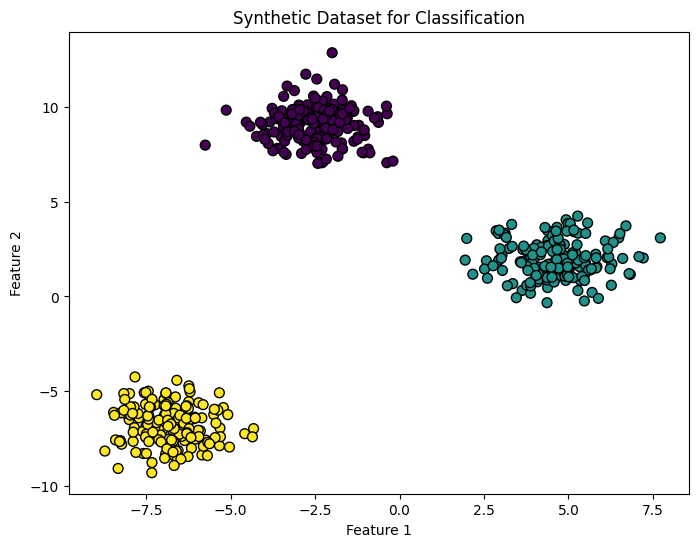

In [3]:
# 1. Generate a synthetic dataset
# We create 3 distinct blobs of data for a 3-class classification problem.
X, y = make_blobs(n_samples=500, centers=3, n_features=2, random_state=42)

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# 3. Instantiate and train our classifier
nb_scratch = NaiveBayes()
nb_scratch.fit(X_train, y_train)

# 4. Make predictions
predictions = nb_scratch.predict(X_test)

# 5. Calculate and print the accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy of our scratch Naive Bayes classifier: {accuracy * 100:.2f}%")

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
plt.title("Synthetic Dataset for Classification")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Compare with Scikit-learn's GaussianNB

In [4]:
from sklearn.naive_bayes import GaussianNB

# 1. Instantiate and train the scikit-learn model
gnb_sklearn = GaussianNB()
gnb_sklearn.fit(X_train, y_train)

# 2. Make predictions
predictions_sklearn = gnb_sklearn.predict(X_test)

# 3. Calculate and print the accuracy
accuracy_sklearn = accuracy_score(y_test, predictions_sklearn)
print(f"Accuracy of scikit-learn's GaussianNB classifier: {accuracy_sklearn * 100:.2f}%")

Accuracy of scikit-learn's GaussianNB classifier: 100.00%


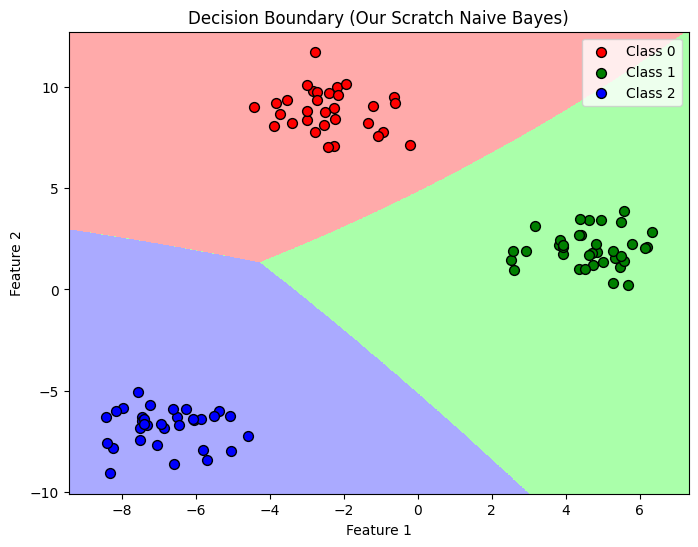

In [5]:
def plot_decision_boundary(X, y, classifier, title):
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['red', 'green', 'blue']

    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_light)

    # Plot the training points
    for i, color in zip(np.unique(y), cmap_bold):
        plt.scatter(X[y == i, 0], X[y == i, 1], c=color, label=f'Class {i}', edgecolor='black', s=50)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# Plot the decision boundary for our scratch model
plot_decision_boundary(X_test, y_test, nb_scratch, "Decision Boundary (Our Scratch Naive Bayes)")